In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "risqullah.xlsx"
dataraw = pd.read_excel(path)

print("--- DATA MAHASISWA LENGKAP ---")
print(dataraw)
print(f"\nTotal Data: {dataraw.shape[0]} baris, {dataraw.shape[1]} kolom")

--- DATA MAHASISWA LENGKAP ---
           NIM                Name  KUIS  UTS  UAS  Nilai Grade
0   2455301097         M.Risqullah    85   90   87  87.35     A
1       120001            John Doe    85   78   90  84.44     A
2       120005          Jane Smith    92   88   94  91.38     A
3       120017     Michael Johnson    48   65   56  56.41     C
4       120018         Emily Brown    90   85   88  87.65     A
5       120022     Daniel Martinez    75   80   77  77.35    AB
6       120024        Sarah Wilson    88   70   65  74.01     B
7       120025        David Garcia    75   70   75  73.35     B
8       120027         Jessica Lee    95   91   96  94.03     A
9       120034       Matthew Davis    79   84   78  80.30    AB
10      120035  Jennifer Rodriguez    42   48   63  51.33     C
11      120036       Andrew Taylor    53   64   59  58.73     C
12      120038    Amanda Hernandez    91   95   90  91.97     A
13      120039   Christopher Clark    76   81   75  77.30    AB
14      1

In [33]:
order_grades = ["A", "AB", "B", "BC", "C", "F"]
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
datafrq = datafrq.reindex(order_grades).fillna(0).astype(int)
datafrq["Persentase"] = ((datafrq["Frekuensi"] / len(dataraw)) * 100).round(1)

print("--- TABEL FREKUENSI ---")
print(datafrq)

--- TABEL FREKUENSI ---
col_0  Frekuensi  Persentase
Grade                       
A             13        41.9
AB             7        22.6
B              4        12.9
BC             1         3.2
C              5        16.1
F              1         3.2


/tmp/ipykernel_615/3379815249.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


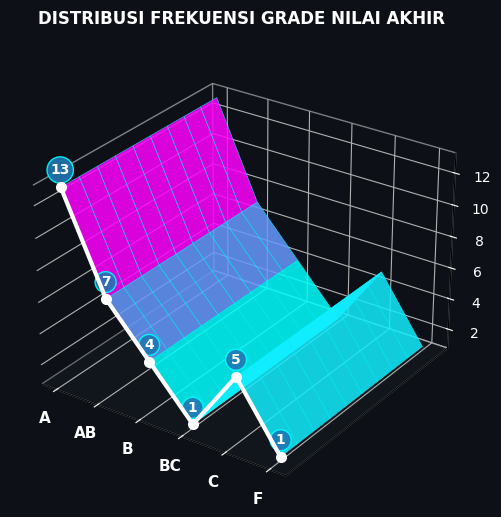

In [34]:
fig = plt.figure(figsize=(9, 6), facecolor="#0d1117")
ax = fig.add_subplot(111, projection="3d", facecolor="#0d1117")

x = np.arange(len(order_grades))
z = datafrq["Frekuensi"].values

Y = np.linspace(0, 1.2, 10)
X_mesh, Y_mesh = np.meshgrid(x, Y)
Z_mesh = np.tile(z, (len(Y), 1))

ax.plot_surface(X_mesh, Y_mesh, Z_mesh, cmap="cool", alpha=0.85, edgecolor="#00f2fe", linewidth=0.4)
ax.plot(x, np.zeros_like(x), z, color="white", linewidth=3, marker="o", markersize=7, zorder=10)

for xi, zi in zip(x, z):
    ax.text(xi, 0, zi + 0.8, f"{zi}", color="white", fontweight="bold", fontsize=10, ha="center",
            bbox=dict(boxstyle="circle,pad=0.25", facecolor="#1f77b4", edgecolor="cyan", alpha=0.9))

ax.set_xticks(x)
ax.set_xticklabels(order_grades, color="white", fontweight="bold", fontsize=11)
ax.set_yticks([])
ax.set_zlabel("Frekuensi", color="white", labelpad=10)
ax.tick_params(colors="white")

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = True
ax.zaxis.pane.set_facecolor("#161b22")
ax.grid(color="#30363d", linestyle=":", alpha=0.5)

ax.view_init(elev=28, azim=-55)
ax.set_title("DISTRIBUSI FREKUENSI GRADE NILAI AKHIR", color="white", fontsize=12, pad=15, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_615/2854018050.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


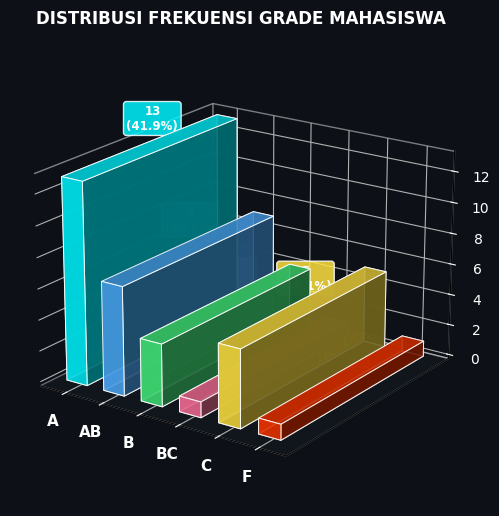

In [35]:
fig = plt.figure(figsize=(9, 6), facecolor="#0d1117")
ax = fig.add_subplot(111, projection="3d", facecolor="#0d1117")

x = np.arange(len(order_grades))
z = np.zeros(len(order_grades))
dx = 0.55 * np.ones(len(order_grades))
dy = 0.55 * np.ones(len(order_grades))
dz = datafrq["Frekuensi"].values

neon_colors = ["#00f2fe", "#4facfe", "#43e97b", "#fa709a", "#fee140", "#f83600"]

# Ubin lantai dasar
for xi in x:
    ax.bar3d(xi, 0, 0, dx[0], dy[0], 0.1, color="#1e2638", alpha=0.9, edgecolor="#30363d")

# Pilar 3D utama
ax.bar3d(x, np.zeros_like(x), z, dx, dy, dz, color=neon_colors, alpha=0.88, edgecolor="white", linewidth=0.7, shade=True)

# Lencana nilai di pucuk pilar
for xi, dzi, c in zip(x, dz, neon_colors):
    pct = datafrq.loc[order_grades[xi], "Persentase"]
    ax.text(xi + dx[0]/2, dy[0]/2, dzi + 0.9, f"{dzi}\n({pct}%)",
            color="white", fontweight="bold", fontsize=8.5, ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.25", facecolor=c, edgecolor="white", alpha=0.85))

ax.set_xticks(x + dx[0]/2)
ax.set_xticklabels(order_grades, color="white", fontweight="bold", fontsize=11)
ax.set_yticks([])
ax.set_zlabel("Jumlah Mahasiswa", color="white", labelpad=10)
ax.tick_params(colors="white")

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = True
ax.zaxis.pane.set_facecolor("#161b22")
ax.grid(color="#30363d", linestyle=":", alpha=0.5)

ax.view_init(elev=20, azim=-55)
ax.set_title("DISTRIBUSI FREKUENSI GRADE MAHASISWA", color="white", fontsize=12, pad=15, fontweight="bold")
plt.tight_layout()
plt.show()

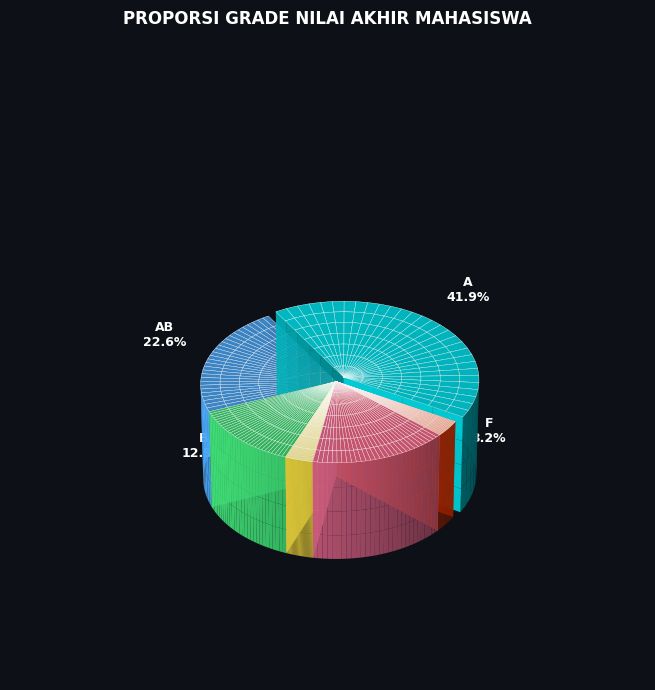

In [36]:
fig = plt.figure(figsize=(8, 7), facecolor="#0d1117")
ax = fig.add_subplot(111, projection="3d", facecolor="#0d1117")

angles = np.array([0] + list(np.cumsum(datafrq["Frekuensi"] / datafrq["Frekuensi"].sum() * 2 * np.pi)))
height = 0.35
r = 1.0
neon_colors = ["#00f2fe", "#4facfe", "#43e97b", "#fee140", "#fa709a", "#f83600"]

for i in range(len(order_grades)):
    t_start, t_end = angles[i], angles[i+1]
    c = neon_colors[i]

    explode_shift = 0.08 if order_grades[i] == "A" else 0.0
    mid_angle = (t_start + t_end) / 2
    shift_x = explode_shift * np.cos(mid_angle)
    shift_y = explode_shift * np.sin(mid_angle)

    t_vals = np.linspace(t_start, t_end, 30)

    # Dinding lengkung silinder
    T, Z_side = np.meshgrid(t_vals, np.linspace(0, height, 5))
    ax.plot_surface(r * np.cos(T) + shift_x, r * np.sin(T) + shift_y, Z_side, color=c, alpha=0.9, shade=True, edgecolor="none")

    # Dinding radial irisan
    for t_edge in [t_start, t_end]:
        R_edge, Z_edge = np.meshgrid(np.linspace(0, r, 5), np.linspace(0, height, 5))
        ax.plot_surface(R_edge * np.cos(t_edge) + shift_x, R_edge * np.sin(t_edge) + shift_y, Z_edge, color=c, alpha=0.9, shade=True, edgecolor="none")

    # Cakram penutup atas
    R_top, T_top = np.meshgrid(np.linspace(0, r, 8), t_vals)
    ax.plot_surface(R_top * np.cos(T_top) + shift_x, R_top * np.sin(T_top) + shift_y, np.full_like(R_top, height),
                    color=c, alpha=0.95, shade=True, edgecolor="white", linewidth=0.25)

    # Label grade dan persentase
    lx = 1.35 * np.cos(mid_angle) + shift_x
    ly = 1.35 * np.sin(mid_angle) + shift_y
    pct = datafrq.loc[order_grades[i], "Persentase"]
    ax.text(lx, ly, height + 0.05, f"{order_grades[i]}\n{pct}%", color="white", fontweight="bold", fontsize=9, ha="center", va="center")

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(0, 0.9)
ax.axis("off")

ax.view_init(elev=35, azim=-60)
ax.set_title("PROPORSI GRADE NILAI AKHIR MAHASISWA", color="white", fontsize=12, pad=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [37]:
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors="coerce")
dt = dataraw["Nilai"]

stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"] = dt.median()
stats["Mode"] = dt.mode().iloc[0]
stats["variance"] = dt.var()
stats["range"] = dt.max() - dt.min()
stats["skewness"] = dt.skew()
stats["kurtosis"] = dt.kurtosis()

print("--- STATISTIKA DESKRIPTIF NILAI AKHIR ---")
print(stats.round(4))

--- STATISTIKA DESKRIPTIF NILAI AKHIR ---
count              31.0000
mean               76.5803
std                13.3903
min                46.0100
25%                68.8000
50%                79.3000
75%                87.3200
max                94.0300
Standard Error      2.4050
Median             79.3000
Mode               77.3000
variance          179.2990
range              48.0200
skewness           -0.7171
kurtosis           -0.4636
Name: Nilai, dtype: float64
